# Online Shoppers Purchasing Intention — Veri On Isleme

Kaynak veri: `online_shoppers_intention.csv`  
Kaynak: https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset

## 1. Degiskenler Hakkında Bilgilendirme

### Sayfa Etkilesimleri

| Degisken | Tur | Aciklama |
|---|---|---|
| Administrative | int | Idari sayfa ziyaret sayisi (hesap, sifre vb.) |
| Administrative_Duration | float | Idari sayfalarda gecirilen sure (sn) |
| Informational | int | Bilgilendirici sayfa ziyaret sayisi (iletisim, hakkinda vb.) |
| Informational_Duration | float | Bilgilendirici sayfalarda gecirilen sure (sn) |
| ProductRelated | int | Urun sayfasi ziyaret sayisi |
| ProductRelated_Duration | float | Urun sayfalarinda gecirilen sure (sn) |

### Google Analytics Metrikleri

| Degisken | Tur | Aciklama |
|---|---|---|
| BounceRates | float | Kullanicinin gezdigi sayfalarin hemen cikis orani ortalamasi |
| ExitRates | float | Kullanicinin gezdigi sayfalarin gecmiste son sayfa olma orani ortalamasi |
| PageValues | float | Satin alma oncesi ziyaret edilen sayfalarin ortalama degeri; hedef degiskeni en guclu etkileyen ozellik |

### Zaman ve Sezonsallik

| Degisken | Tur | Aciklama |
|---|---|---|
| SpecialDay | float | Ziyaretin ozel bir gune yakinligi (0-1; 1 = ozel gun) |
| Month | str | Ziyaret ayi |
| Weekend | bool | Hafta sonu ziyareti |

### Ziyaretci Ozellikleri

Sayisal gorunseler de kategorik (nominal) degiskenlerdir.

| Degisken | Tur | Aciklama |
|---|---|---|
| OperatingSystems | int | Isletim sistemi kodu |
| Browser | int | Tarayici kodu |
| Region | int | Cografya bolge kodu |
| TrafficType | int | Trafik kaynagi kodu (reklam, dogrudan, referans vb.) |
| VisitorType | str | Returning_Visitor / New_Visitor / Other |

### Hedef Degisken

| Degisken | Tur | Aciklama |
|---|---|---|
| Revenue | bool | Oturumun satin alimla sonuclanip sonuclanmadigi |

## 2. Kutuphaneler ve Veri Yukleme

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")
print(f"Veri boyutu: {df.shape}")
df.head()

Veri boyutu: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Genel Inceleme

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
print(f"Tekrar eden satir sayisi: {df.duplicated().sum()}")

Tekrar eden satir sayisi: 125


In [5]:
df_raw = df.copy()
print(f"Ham veri boyutu: {df_raw.shape}")

Ham veri boyutu: (12330, 18)


## 4. Tekrar Eden Satirlarin Kaldirilmasi

In [6]:
df = df.drop_duplicates()
print(f"Temizlenmis veri boyutu : {df.shape}")
print(f"Kaldirilan satir sayisi : {df_raw.shape[0] - df.shape[0]}")

Temizlenmis veri boyutu : (12205, 18)
Kaldirilan satir sayisi : 125


## 5. Tanimlayici Istatistikler

In [7]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [8]:
# Informational: ziyaret sayisi 0 oldugu halde sure > 0 olan satirlari incele
summary_df = pd.DataFrame({
    "Informational":          df["Informational"],
    "Informational_Duration": df["Informational_Duration"],
})
display(summary_df.value_counts().reset_index(name="Count"))

,Informational,Informational_Duration,Count
0,0,0.000000,9574
1,1,0.000000,217
2,1,6.000000,17
3,2,7.000000,15
4,2,9.000000,15
...,...,...,...
1652,2,182.200000,1
1653,2,178.000000,1
1654,2,176.000000,1
1655,2,175.500000,1


## 6. Tutarsizlik Kontrolu

Sayfa ziyaret sayisi 0 iken gecirilen surenin 0'dan buyuk olmasi
mantiksal tutarsizliktir. Bu kontrol tutarsiz satir sayisini ortaya koyar.

In [9]:
checks = {
    "Administrative": (df["Administrative"] == 0) & (df["Administrative_Duration"] > 0),
    "Informational":  (df["Informational"]  == 0) & (df["Informational_Duration"]  > 0),
    "ProductRelated": (df["ProductRelated"] == 0) & (df["ProductRelated_Duration"] > 0),
}

for col, mask in checks.items():
    print(f"{col:<20} tutarsiz satir: {mask.sum()}")

Administrative       tutarsiz satir: 0
Informational        tutarsiz satir: 0
ProductRelated       tutarsiz satir: 0


## 7. Sutun Ozeti

In [10]:
summary_table = pd.DataFrame({
    "Essiz Deger Sayisi": df.nunique(),
    "Veri Tipi":          df.dtypes,
}).sort_values(by="Essiz Deger Sayisi")

display(summary_table)

,Essiz Deger Sayisi,Veri Tipi
Revenue,2,bool
Weekend,2,bool
VisitorType,3,object
SpecialDay,6,float64
OperatingSystems,8,int64
Region,9,int64
Month,10,object
Browser,13,int64
Informational,17,int64
TrafficType,20,int64


## 8. Kategorik Degisken Dagilimi

,count
Revenue,
False,10297
True,1908


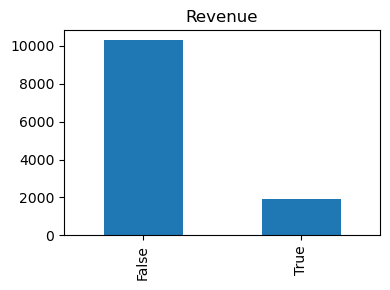

----------------------------------------


,count
Weekend,
False,9346
True,2859


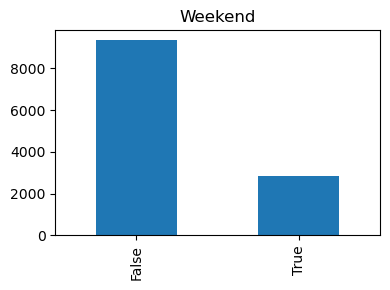

----------------------------------------


,count
VisitorType,
Returning_Visitor,10431
New_Visitor,1693
Other,81


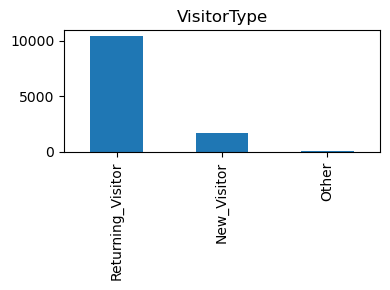

----------------------------------------


,count
SpecialDay,
0.0,10956
0.6,350
0.8,324
0.4,243
0.2,178
1.0,154


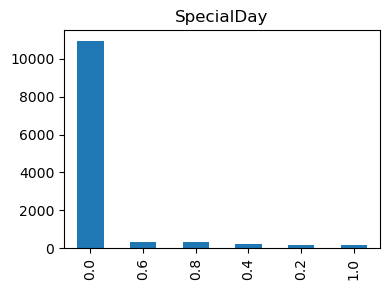

----------------------------------------


,count
OperatingSystems,
2,6541
1,2549
3,2530
4,478
8,75
6,19
7,7
5,6


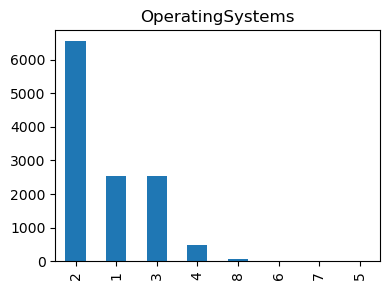

----------------------------------------


,count
Region,
1,4714
3,2379
4,1171
2,1128
6,801
7,758
9,505
8,431
5,318


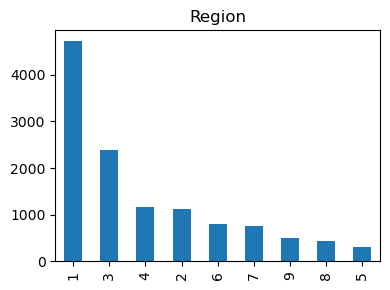

----------------------------------------


,count
Browser,
2,7883
1,2427
4,731
5,465
6,174
10,163
8,135
3,105
13,56


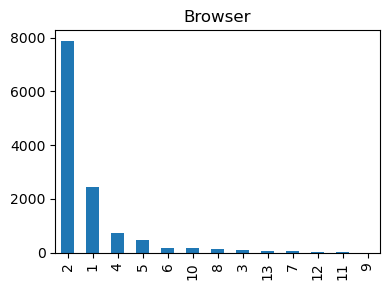

----------------------------------------


In [11]:
categorical_cols = [
    "Revenue", "Weekend", "VisitorType",
    "SpecialDay", "OperatingSystems", "Region", "Browser",
]

for col in categorical_cols:
    display(df[col].value_counts().to_frame())
    df[col].value_counts().plot(kind="bar", figsize=(4, 3), title=col)
    plt.xlabel("")
    plt.tight_layout()
    plt.show()
    print("-" * 40)

In [12]:
df.to_csv("cleaned.csv")
print(f"Kaydedildi: cleaned.csv  ({df.shape[0]:,} satir, {df.shape[1]} sutun)")

Kaydedildi: cleaned.csv  (12,205 satir, 18 sutun)
